In [1]:
from google.colab import files
uploaded = files.upload()

Saving produce.csv to produce.csv


In [3]:
import pandas as pd

df = pd.read_csv('produce.csv')
df.head()

,Particulars,Frequency,Unit,3-1993,3-1994,3-1995,3-1996,3-1997,3-1998,3-1999,...,3-2005,3-2006,3-2007,3-2008,3-2009,3-2010,3-2011,3-2012,3-2013,3-2014
0,Agricultural Production Foodgrains,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,198.36282,208.6016,217.28212,230.77504,234.466177,218.107372,244.491809,259.286253,257.13,264.3806
1,Agricultural Production Foodgrains Kharif,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,103.30942,109.8734,110.57622,120.95724,118.138577,103.954032,120.853191,131.274812,128.07,129.3686
2,Agricultural Production Foodgrains Rabi,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.05340,98.7282,106.70590,109.81780,116.327600,114.153340,123.638618,128.011441,129.06,135.0120
3,Agricultural Production Foodgrains Rice,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,83.13170,91.7934,93.35530,96.69290,99.182500,89.092901,95.979819,105.301100,105.24,106.2872
4,Agricultural Production Foodgrains Rice Kharif,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,72.23000,78.2719,80.17080,82.65940,84.908200,75.916510,80.651241,92.780700,92.37,92.0093


In [4]:
# Data shape paakalam
print(df.shape)
print(df.columns.tolist())

(429, 25)
['Particulars', 'Frequency', 'Unit', ' 3-1993', ' 3-1994', ' 3-1995', ' 3-1996', ' 3-1997', ' 3-1998', ' 3-1999', ' 3-2000', ' 3-2001', ' 3-2002', ' 3-2003', ' 3-2004', ' 3-2005', ' 3-2006', ' 3-2007', ' 3-2008', ' 3-2009', ' 3-2010', ' 3-2011', ' 3-2012', ' 3-2013', ' 3-2014']


In [5]:
# Wide format ah long format ku convert pannurom
df_long = df.melt(
    id_vars=['Particulars', 'Frequency', 'Unit'],
    var_name='Year',
    value_name='Production'
)

# Year column la irundhu extra text/spaces clean pannurom (e.g. " 3-1993" -> 1993)
df_long['Year'] = df_long['Year'].str.strip().str.replace('3-', '', regex=False).astype(int)

# NaN (missing) values irukura rows ah remove pannurom
df_long = df_long.dropna(subset=['Production'])

# Result paakalam
print(df_long.shape)
df_long.head(10)

(4272, 5)


,Particulars,Frequency,Unit,Year,Production
321,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1993,0.0
328,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1993,0.0
333,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1993,0.0
750,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1994,0.0
757,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1994,0.0
760,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1994,0.0
762,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1994,0.0
1179,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1995,0.0
1186,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1995,0.0
1189,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1995,0.0


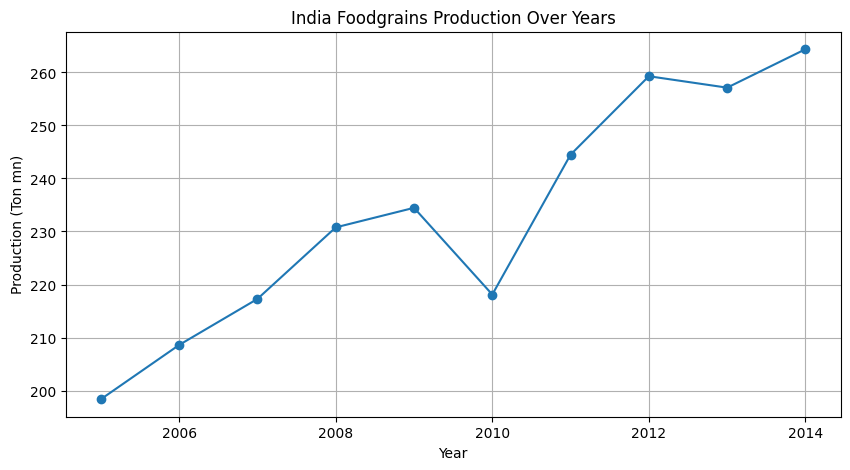

In [6]:
import matplotlib.pyplot as plt

# Total foodgrains production trend paakalam (year by year)
foodgrains = df_long[df_long['Particulars'] == 'Agricultural Production Foodgrains']

plt.figure(figsize=(10,5))
plt.plot(foodgrains['Year'], foodgrains['Production'], marker='o')
plt.title('India Foodgrains Production Over Years')
plt.xlabel('Year')
plt.ylabel('Production (Ton mn)')
plt.grid(True)
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Crop name (Particulars) ah number ah convert pannurom
le = LabelEncoder()
df_long['Particulars_encoded'] = le.fit_transform(df_long['Particulars'])

# Features (X) and Target (y) define pannurom
X = df_long[['Particulars_encoded', 'Year']]
y = df_long['Production']

# Train and Test data ah split pannurom (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model create pannurom and train pannurom
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test data la predict pannurom
predictions = model.predict(X_test)

# Model evaluate pannurom
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 122.76993242585498
R2 Score: 0.9651466285686308


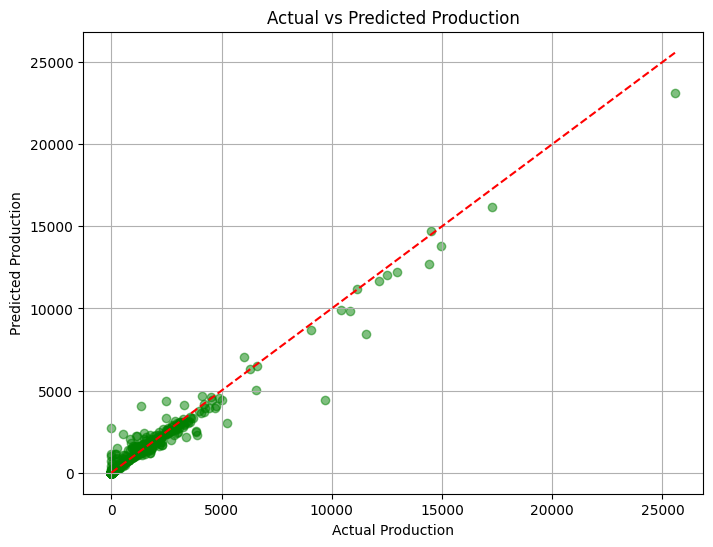

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.title('Actual vs Predicted Production')
plt.xlabel('Actual Production')
plt.ylabel('Predicted Production')
plt.grid(True)
plt.show()